# Labeling the angular character of Yb 171

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

import rydstate

logging.getLogger("rydstate").setLevel(logging.ERROR)

In [2]:
nu = 0, 130
l_r = 0
f_tot = 1 / 2

basis = rydstate.BasisMQDT("Yb171", nu, f_tot=(f_tot, f_tot), include_sqdt_fallback_models=False)

In [3]:
print(f"Number of states in basis: {len(basis.states)}")
print("States in basis:")
for state in basis.states[:3]:
    print(state)
print("... ")

Number of states in basis: 781
States in basis:
-0.00011904947676346527*(Yb171, RadialKet(nu=1.8192961066009463, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=1, j_c=0.5, f_c=1.0, j_r=1.5, f_tot=0.5)), 0.8659476823364968*(Yb171, RadialKet(nu=1.8192961066009463, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=1, j_c=0.5, f_c=1.0, j_r=0.5, f_tot=0.5)), -0.5001345791717184*(Yb171, RadialKet(nu=1.8193076771654273, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=1, j_c=0.5, f_c=0.0, j_r=0.5, f_tot=0.5))
0.6869979641992596*(Yb171, RadialKet(nu=1.8389122687565478, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=1, j_c=0.5, f_c=1.0, j_r=1.5, f_tot=0.5)), 0.3634927778183221*(Yb171, RadialKet(nu=1.8389122687565478, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=1, j_c=0.5, f_c=1.0, j_r=0.5, 

In [4]:
basis.filter_states("j_tot", (0, float("inf")), keep_unknown=False)
basis.filter_states("f_c", (0, float("inf")), keep_unknown=False)
basis.filter_states("f_tot", f_tot)
basis.filter_states("l_r", l_r, delta=0.5)
basis.filter_states("l_c", 0, delta=0.3)

basis.sort_states("nu")

print(f"{basis.species} basis states: {len(basis)}")
print(f"  nu_min = {basis.states[0].nu}, nu_max = {basis.states[-1].nu}")

Yb171 basis states: 262
  nu_min = 2.501251480202191, nu_max = 129.68494203492332


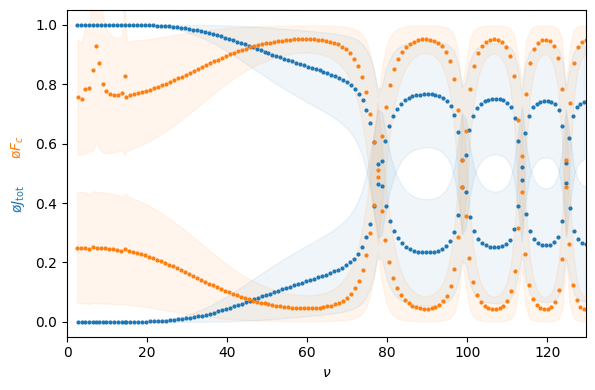

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

qns_of_interest = ["j_tot", "f_c"]
legend_labels = {
    "f_tot": r"F_{\mathrm{tot}}",
    "s_tot": r"S_{\mathrm{tot}}",
    "l_tot": r"L_{\mathrm{tot}}",
    "j_tot": r"J_{\mathrm{tot}}",
    "j_r": r"j_{r}",
    "f_c": r"F_{c}",
    "i_c": r"I",
}

nu = basis.calc_exp_qn("nu")
for j, qn in enumerate(qns_of_interest):
    exp = basis.calc_exp_qn(qn)
    std = basis.calc_std_qn(qn) ** 2

    mean = np.mean(exp)
    for which in ["lower", "upper"]:
        idx = np.argwhere(exp < mean) if which == "lower" else np.argwhere(exp >= mean)

        exp_i = exp[idx].flatten()
        std_i = std[idx].flatten()
        nu_i = nu[idx].flatten()

        ax.plot(nu_i, exp_i, f"C{j}o", ms=2)
        ax.fill_between(nu_i, exp_i - std_i, exp_i + std_i, color=f"C{j}", alpha=0.07)


# labels
ax.set_xlabel(r"$\nu$")
ax.set_ylabel("")
for j, qn in enumerate(qns_of_interest):
    label = rf"$\mathrm{{\o}} {legend_labels[qn]}$"
    ax.text(-0.11, 0.5 + (2 * j - 1) * 0.08, label, transform=ax.transAxes, rotation=90, va="center", color=f"C{j}")

# lims
ax.set_xlim(0, nu[-1])
ax.set_ylim(-0.05, 1.05)

fig.tight_layout()
plt.show()

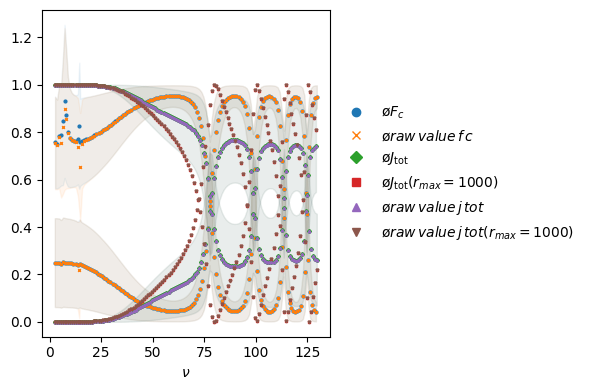

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

qns_of_interest = ["f_c", "raw_value_f_c", "j_tot", "raw_value_j_tot"]
legend_labels = {
    "f_tot": r"F_{\mathrm{tot}}",
    "s_tot": r"S_{\mathrm{tot}}",
    "l_tot": r"L_{\mathrm{tot}}",
    "j_tot": r"J_{\mathrm{tot}}",
    "j_r": r"j_{r}",
    "f_c": r"F_{c}",
    "i_c": r"I",
}
markers = ["o", "x", "D", "s", "^", "v", "<", ">"] * 10

j = 0
labels = {}

nu = basis.calc_exp_qn("nu")
for qn in qns_of_interest:
    legen_label = legend_labels.get(qn, qn.replace("_", r"\,"))
    exp = basis.calc_exp_qn(qn)
    std = basis.calc_std_qn(qn) ** 2

    mean = np.mean(exp)
    for which in ["lower", "upper"]:
        idx = np.argwhere(exp < mean) if which == "lower" else np.argwhere(exp >= mean)

        exp_i = exp[idx].flatten()
        std_i = std[idx].flatten()
        nu_i = nu[idx].flatten()

        ax.plot(nu_i, exp_i, f"C{j}{markers[j]}", ms=2)
        ax.fill_between(nu_i, exp_i - std_i, exp_i + std_i, color=f"C{j}", alpha=0.07)
    labels[j] = rf"$\mathrm{{\o}} {legen_label}$"
    j += 1

    if "f_c" in qn:
        continue

    for r_max in [1000]:
        exp_short_range = basis.calc_short_range_exp_qn(qn, r_max=r_max)
        mean = np.mean(exp_short_range)
        for which in ["lower", "upper"]:
            idx = np.argwhere(exp_short_range < mean) if which == "lower" else np.argwhere(exp_short_range >= mean)

            exp_short_range_i = exp_short_range[idx].flatten()
            nu_i = nu[idx].flatten()

            ax.plot(nu_i, exp_short_range_i, f"C{j}{markers[j]}", ms=2)
        labels[j] = rf"$\mathrm{{\o}} {legen_label} (r_{{max}}={r_max})$"
        j += 1


# labels
ax.set_xlabel(r"$\nu$")
ax.set_ylabel("")
for j, label in labels.items():
    ax.plot([], [], f"C{j}{markers[j]}", label=label)

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

fig.tight_layout()
plt.show()